# LSE Dividend + EPS Growth — Research Notebook
**Signal**: 0.4 × Trailing-12M Yield Rank + 0.6 × YoY EPS Growth Rank (cross-sectional)  
**Universe**: LSE dividend-paying stocks (~3,900 tickers, `exchange='LSE'` in EODHD)  
**Strategy**: Top-20 long-only, monthly rebalance, XLON calendar  
**Results**: Sharpe 0.87 | CAGR 8.05% | Max DD −26.3% | Sortino 1.28  

---

### Execution & Cost Assumptions
| Parameter | Value | Notes |
|-----------|-------|-------|
| Signal delay | **1 bar** | Score at close[T] → trade at close[T+1] |
| Order type | **MOC** (Market on Close) | Day order, fills at end-of-day auction |
| Rebalance | **Monthly** | XLON business-day calendar |
| Commission | **10 bps** of notional | Each side (buy + sell both charged) |
| Slippage | **Power-law**: base 2 bps + k=20, exp=0.5 | LSE spreads wider than NYSE |
| Max participation | **5%** of daily volume | Conservative for smaller LSE names |
| Borrow cost | **0%** | Long-only, no short positions |
| Max weight per name | **10%** | Cap at 2× equal-weight for 20 stocks |

---
Run cells top-to-bottom. All charts are interactive (Signum) except heatmaps and bar charts.


In [226]:
import sys, pathlib, os

# Walk up to btest root (has 'strategies/' + 'equities/' subdirs)
ROOT = pathlib.Path.cwd()
for p in [ROOT] + list(ROOT.parents):
    if (p / 'strategies').exists() and (p / 'equities').exists():
        ROOT = p
        break

# Add workspace root to sys.path so local 'signum' package is importable
WORKSPACE = ROOT.parent
for d in [str(WORKSPACE), str(ROOT / 'src')]:
    if d not in sys.path:
        sys.path.insert(0, d)

os.chdir(ROOT)
print(f'Btest root : {ROOT}')
print(f'Workspace  : {WORKSPACE}')

Btest root : c:\Personal\Business & Investments\Python codes\btest
Workspace  : c:\Personal\Business & Investments\Python codes


In [227]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from signum import Chart

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
print('Libraries loaded (signum + matplotlib).')

Libraries loaded (signum + matplotlib).


---
## 1 — Load Data

In [228]:
ATTEMPT = 'research/LSE Dividend EPS/001_baseline'

# ---- Signal parquets (wide: date x ticker) ----------------------------------
composite  = pd.read_parquet(f'{ATTEMPT}/data/composite.parquet')
div_income = pd.read_parquet(f'{ATTEMPT}/data/div_income.parquet')
eps_yoy    = pd.read_parquet(f'{ATTEMPT}/data/eps_yoy_raw.parquet')

# Strip 05:00:00 from signal indices so dates align with price dates
for _df in [composite, div_income, eps_yoy]:
    _df.index = pd.to_datetime(_df.index).normalize()

# ---- Price data (long format -> wide pivot) ----------------------------------
# Columns: date (UTC tz-aware), ticker, open, high, low, close (adj), close_unadj, volume
prices_long = pd.read_parquet(f'{ATTEMPT}/data/lse_prices.parquet')
prices_long['_date'] = pd.to_datetime(prices_long['date']).dt.tz_convert(None).dt.normalize()
adj_px   = prices_long.pivot_table(index='_date', columns='ticker', values='close')        # adj close
close_px = prices_long.pivot_table(index='_date', columns='ticker', values='close_unadj')  # unadjusted
# Ensure both indices are tz-naive (pivot may preserve tz if input still had it)
adj_px.index   = pd.to_datetime(adj_px.index).tz_localize(None)
close_px.index = pd.to_datetime(close_px.index).tz_localize(None)

# ---- Backtest outputs -------------------------------------------------------
eq     = pd.read_parquet(f'{ATTEMPT}/outputs/equity.parquet')
trades = pd.read_parquet(f'{ATTEMPT}/outputs/trades.parquet')
wts    = pd.read_parquet(f'{ATTEMPT}/outputs/weights.parquet')

eq.index  = pd.to_datetime(eq.index).tz_localize(None).normalize()
wts.index = pd.to_datetime(wts.index).tz_localize(None).normalize()
if 'datetime' in trades.columns:
    trades['datetime'] = pd.to_datetime(trades['datetime']).dt.tz_localize(None)

with open(f'{ATTEMPT}/outputs/summary.json') as f:
    summary = json.load(f)

start_trade = eq[eq['leverage'] > 0].index[0]
end_trade   = eq.index[-1]

print(f'Composite  : {composite.index.min().date()} -> {composite.index.max().date()}')
print(f'  avg coverage : {composite.notna().sum(axis=1).mean():.0f} tickers/day')
print(f'Prices     : {adj_px.index.min().date()} -> {adj_px.index.max().date()}  ({adj_px.shape[1]} tickers)')
print(f'Active     : {start_trade.date()} -> {end_trade.date()}')
print(f'Trades     : {len(trades):,}')
print()
print('Key metrics from summary.json:')
for k in ['sharpe', 'cagr', 'max_dd', 'sortino', 'calmar', 'turnover_annual']:
    if k in summary:
        print(f'  {k:<20}: {summary[k]}')


Composite  : 2015-01-02 -> 2026-05-06
  avg coverage : 924 tickers/day
Prices     : 2013-01-02 -> 2026-05-06  (3939 tickers)
Active     : 2015-01-05 -> 2025-12-31
Trades     : 63,264

Key metrics from summary.json:


---
## 2 — Signal Coverage & Distribution

In [229]:
# Interactive: tickers with a valid composite signal per day
coverage = composite.notna().sum(axis=1)
coverage.index = pd.to_datetime(coverage.index)

Chart(height=300).area(
    coverage.rename('Tickers with Signal'),
    name='Universe coverage'
).show()

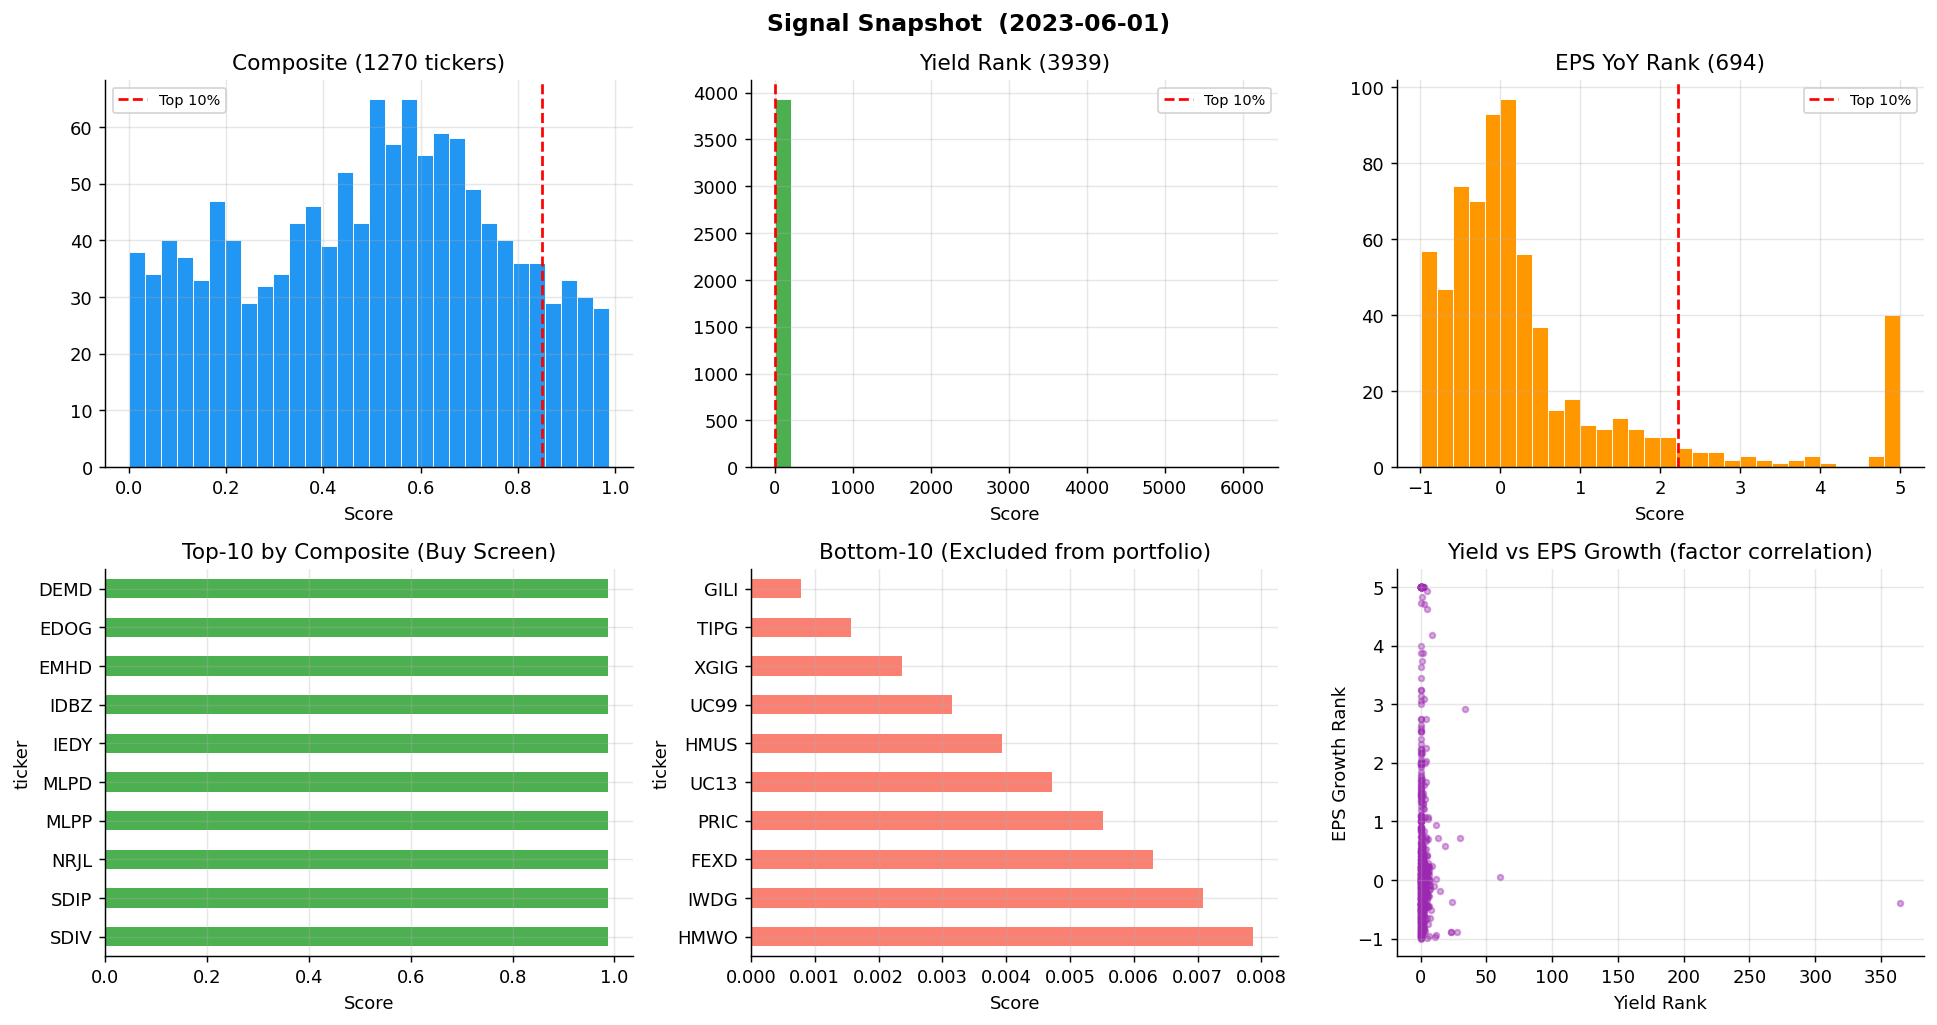

In [230]:
# Score distribution + top/bottom names on a recent sample date
sample_date = composite.loc[composite.index >= '2023-06-01'].index[0]
sample_row  = composite.loc[sample_date].dropna()
div_row     = div_income.loc[div_income.index >= '2023-06-01'].iloc[0].dropna()
eps_row     = eps_yoy.loc[eps_yoy.index >= '2023-06-01'].iloc[0].dropna()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Signal Snapshot  ({sample_date.date()})', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0, 0], sample_row, f'Composite ({len(sample_row)} tickers)', '#2196F3'),
    (axes[0, 1], div_row,   f'Yield Rank ({len(div_row)})', '#4CAF50'),
    (axes[0, 2], eps_row,   f'EPS YoY Rank ({len(eps_row)})', '#FF9800'),
]:
    ax.hist(data.values, bins=30, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(data.quantile(0.9), color='red', linestyle='--', linewidth=1.5, label='Top 10%')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

sample_row.nlargest(10).plot(kind='barh', ax=axes[1, 0], color='#4CAF50')
axes[1, 0].set_title('Top-10 by Composite (Buy Screen)')
axes[1, 0].set_xlabel('Score')
axes[1, 0].invert_yaxis()

sample_row.nsmallest(10).plot(kind='barh', ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Bottom-10 (Excluded from portfolio)')
axes[1, 1].set_xlabel('Score')
axes[1, 1].invert_yaxis()

common = div_row.index.intersection(eps_row.index)
axes[1, 2].scatter(div_row[common], eps_row[common], alpha=0.4, s=10, color='#9C27B0')
axes[1, 2].set_xlabel('Yield Rank')
axes[1, 2].set_ylabel('EPS Growth Rank')
axes[1, 2].set_title('Yield vs EPS Growth (factor correlation)')

plt.tight_layout()
plt.show()

---
## 3 — Signal Quality (IC Analysis)

In [231]:
# Spearman IC: composite score vs 1-month forward capital return
comp_active  = composite.loc[(composite.index >= start_trade) & (composite.index <= end_trade)]
close_active = close_px.loc[(close_px.index >= start_trade) & (close_px.index <= end_trade)]

fwd_ret = close_active.pct_change(21).shift(-21)  # forward 21-bar price return

ics, quintile_rets = [], {q: [] for q in range(1, 6)}

for dt in comp_active.index[::21]:   # sample every ~month
    if dt not in fwd_ret.index:
        continue
    scores = comp_active.loc[dt].dropna()
    fwd    = fwd_ret.loc[dt].reindex(scores.index).dropna()
    common = scores.index.intersection(fwd.index)
    if len(common) < 20:
        continue
    s, f = scores[common], fwd[common]
    ics.append({'date': dt, 'ic': s.corr(f, method='spearman')})
    q = pd.qcut(s, 5, labels=False) + 1
    for qi in range(1, 6):
        quintile_rets[qi].append({'date': dt, 'ret': f[q == qi].mean()})

ic_series = pd.DataFrame(ics).set_index('date')['ic']
q_series  = {qi: pd.DataFrame(quintile_rets[qi]).set_index('date')['ret'] for qi in range(1, 6)}

print(f'IC mean : {ic_series.mean():.4f}')
print(f'IC std  : {ic_series.std():.4f}')
print(f'ICIR    : {ic_series.mean() / ic_series.std():.3f}')
print(f'IC > 0  : {(ic_series > 0).mean():.1%}')

IC mean : -0.0318
IC std  : 0.1317
ICIR    : -0.242
IC > 0  : 41.4%


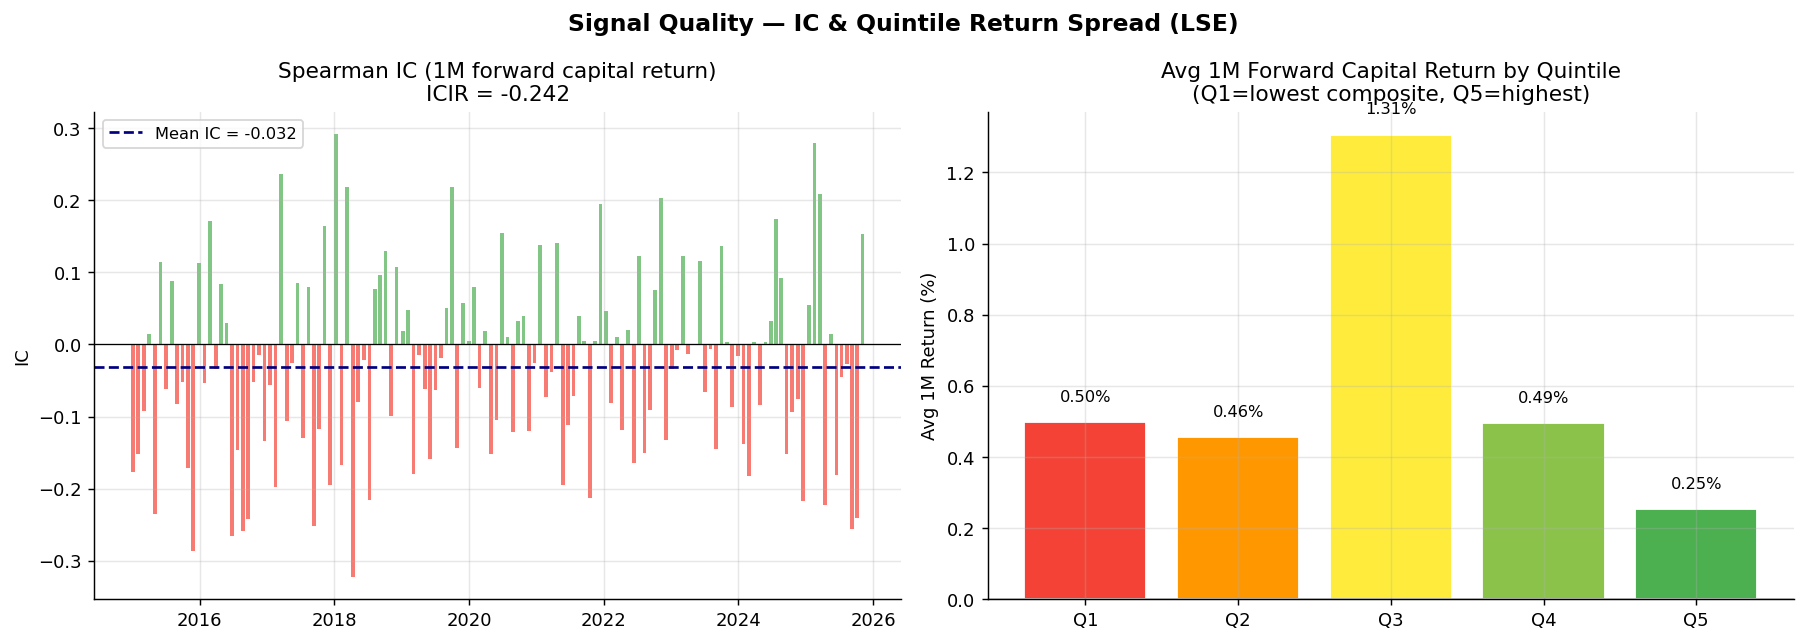

In [232]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Signal Quality — IC & Quintile Return Spread (LSE)', fontsize=13, fontweight='bold')

ax = axes[0]
ic_colors = ['#4CAF50' if v >= 0 else '#f44336' for v in ic_series.values]
ax.bar(ic_series.index, ic_series.values, color=ic_colors, alpha=0.7, width=20)
ax.axhline(ic_series.mean(), color='navy', linewidth=1.5, linestyle='--',
           label=f'Mean IC = {ic_series.mean():.3f}')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title(f'Spearman IC (1M forward capital return)\nICIR = {ic_series.mean() / ic_series.std():.3f}')
ax.set_ylabel('IC')
ax.legend(fontsize=9)

ax = axes[1]
q_means = [q_series[qi].mean() * 100 for qi in range(1, 6)]
bar_colors = ['#f44336', '#ff9800', '#ffeb3b', '#8bc34a', '#4CAF50']
bars = ax.bar([f'Q{i}' for i in range(1, 6)], q_means, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, q_means):
    ax.text(bar.get_x() + bar.get_width() / 2, max(v, 0) + 0.05,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('Avg 1M Forward Capital Return by Quintile\n(Q1=lowest composite, Q5=highest)')
ax.set_ylabel('Avg 1M Return (%)')

plt.tight_layout()
plt.show()

---
## 4 — Equity Curve & Performance

In [233]:
active_eq = eq.loc[eq.index >= start_trade].copy()
nav       = active_eq['equity'] / active_eq['equity'].iloc[0]
roll_max  = nav.cummax()
dd        = (nav - roll_max) / roll_max

daily_ret = active_eq['returns']
ann_ret   = (1 + daily_ret).prod() ** (252 / len(daily_ret)) - 1
ann_vol   = daily_ret.std() * np.sqrt(252)
sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
max_dd    = dd.min()
calmar    = ann_ret / abs(max_dd) if max_dd != 0 else 0
neg_days  = daily_ret[daily_ret < 0]
sortino   = ann_ret / (neg_days.std() * np.sqrt(252)) if len(neg_days) > 0 else 0
win_rate  = (daily_ret[daily_ret != 0] > 0).mean()

print('=== Performance (active period) ===')
print(f'  Period      : {start_trade.date()} -> {end_trade.date()}')
print(f'  Total return: {nav.iloc[-1] - 1:.2%}')
print(f'  CAGR        : {ann_ret:.2%}')
print(f'  Volatility  : {ann_vol:.2%}')
print(f'  Sharpe      : {sharpe:.2f}')
print(f'  Sortino     : {sortino:.2f}')
print(f'  Max DD      : {max_dd:.2%}')
print(f'  Calmar      : {calmar:.2f}')
print(f'  Win rate    : {win_rate:.1%}')

=== Performance (active period) ===
  Period      : 2015-01-05 -> 2025-12-31
  Total return: 139.11%
  CAGR        : 8.05%
  Volatility  : 9.46%
  Sharpe      : 0.85
  Sortino     : 1.10
  Max DD      : -26.27%
  Calmar      : 0.31
  Win rate    : 52.9%


In [234]:
# Interactive NAV curve with stats overlay (Signum)
total_ret = nav.iloc[-1] - 1

(
    Chart(height=420)
    .line(nav.rename('Portfolio NAV'), name='Portfolio NAV', color='#2196F3', width=2)
    .stats_legend({
        'Period':      f'{start_trade.date()} to {end_trade.date()}',
        'Total Return': f'{total_ret:+.1%}',
        'CAGR':        f'{ann_ret:.2%}',
        'Volatility':  f'{ann_vol:.2%}',
        'Sharpe':      f'{sharpe:.2f}',
        'Sortino':     f'{sortino:.2f}',
        'Max DD':      f'{max_dd:.2%}',
        'Calmar':      f'{calmar:.2f}',
        'Win Rate':    f'{win_rate:.1%}',
    }, position='top-left')
    .show()
)


In [235]:
# ── Cost Drag: Gross vs Net NAV ──────────────────────────────────────────────
# Reconstruct gross returns by adding back daily commission + slippage costs

trades_active = trades.copy()
if 'datetime' in trades_active.columns:
    trades_active = trades_active[
        (trades_active['datetime'] >= start_trade) &
        (trades_active['datetime'] <= end_trade)
    ]

# Daily cost in £ (commission + slippage)
has_slippage = 'slippage_bps' in trades_active.columns and 'notional' in trades_active.columns
trades_active['cost'] = trades_active.get('commission', 0)
if has_slippage:
    trades_active['cost'] = (
        trades_active['cost']
        + trades_active['slippage_bps'].fillna(0) * trades_active['notional'].abs() / 10_000
    )

daily_cost = (
    trades_active.groupby(trades_active['datetime'].dt.normalize())['cost'].sum()
    if 'datetime' in trades_active.columns else pd.Series(dtype=float)
)
daily_cost = daily_cost.reindex(active_eq.index, fill_value=0.0)

# Gross return per day = net return + cost / starting equity
start_equity = active_eq['equity'].iloc[0]
daily_cost_pct = daily_cost / start_equity
gross_daily = daily_ret + daily_cost_pct

gross_nav  = (1 + gross_daily).cumprod()
gross_ann  = (gross_nav.iloc[-1]) ** (252 / len(gross_daily)) - 1
drag_ann   = gross_ann - ann_ret
total_cost = daily_cost.sum()

print('=== Cost Drag Summary ===')
print(f'  Gross CAGR        : {gross_ann:.2%}')
print(f'  Net CAGR          : {ann_ret:.2%}')
print(f'  Annual cost drag  : {drag_ann:.2%}  ({drag_ann * 100:.1f} bps/yr)')
print(f'  Total costs (£)   : {total_cost:,.0f}')
print(f'    of which commissions : {trades_active.get("commission", pd.Series(0)).sum():,.0f}')
if has_slippage:
    slip_total = (trades_active['slippage_bps'].fillna(0) * trades_active['notional'].abs() / 10_000).sum()
    print(f'    of which slippage    : {slip_total:,.0f}')

# Gross vs Net NAV (Signum)
Chart(height=380)\
    .line(gross_nav.rename('Gross NAV (before costs)'), color='#9C27B0', width=2)\
    .line(nav.rename('Net NAV (after costs)'),          color='#2196F3', width=2)\
    .stats_legend({
        'Gross CAGR': f'{gross_ann:.2%}',
        'Net CAGR':   f'{ann_ret:.2%}',
        'Cost drag':  f'{drag_ann:.2%} / yr  ({drag_ann * 100:.0f} bps)',
        'Total costs': f'£{total_cost:,.0f}',
    }, position='top-left')\
    .show()

# Cumulative cost drag curve
cum_drag = (gross_nav - nav).rename('Cumulative cost drag (NAV points)')
Chart(height=200)\
    .area(cum_drag, name='Cumulative drag')\
    .show()


=== Cost Drag Summary ===
  Gross CAGR        : 12.72%
  Net CAGR          : 8.05%
  Annual cost drag  : 4.67%  (4.7 bps/yr)
  Total costs (£)   : 475,451
    of which commissions : 353,392
    of which slippage    : 122,059


In [236]:
from signum import Dashboard

# Rolling 63-day Sharpe
rolling_sharpe = (
    daily_ret.rolling(63).mean() / daily_ret.rolling(63).std()
) * np.sqrt(252)

# Two-pane synchronized Dashboard with titles
Dashboard(
    panes=[
        Chart(height=240).baseline((dd * 100).rename('Drawdown (%)'), base_value=0),
        Chart(height=240).baseline(rolling_sharpe.rename('Rolling 63d Sharpe'), base_value=0),
    ],
    titles=['Drawdown (%)', 'Rolling 63-Day Sharpe Ratio'],
).show()


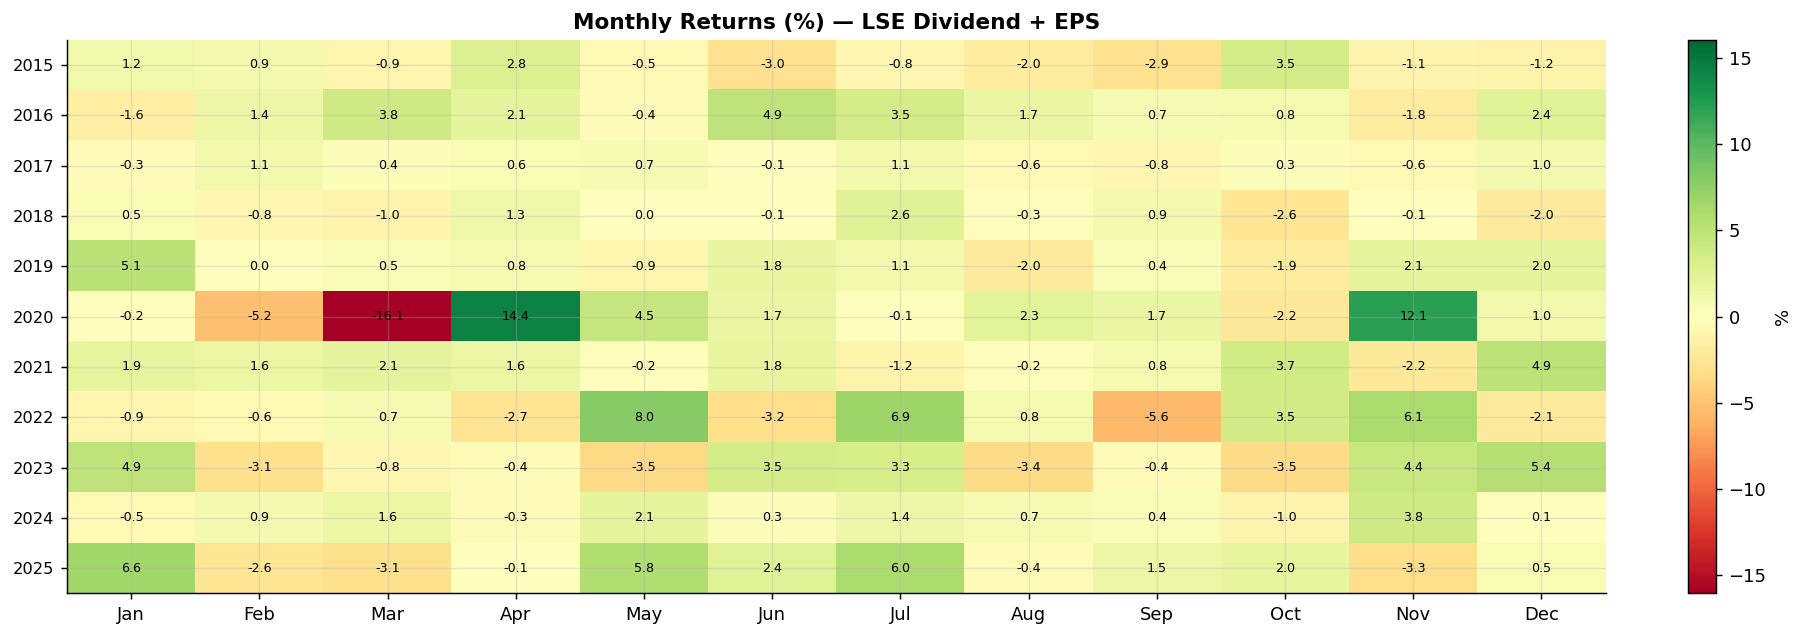

In [237]:
# Monthly returns heatmap (matplotlib - Signum doesn't support categorical grids)
monthly_ret = daily_ret.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_ret.index = monthly_ret.index.to_period('M')
mth_df = monthly_ret.to_frame('ret')
mth_df['year']  = monthly_ret.index.year
mth_df['month'] = monthly_ret.index.month
pivot = mth_df.pivot(index='year', columns='month', values='ret')
vmax  = np.abs(pivot.values[~np.isnan(pivot.values)]).max()

fig, ax = plt.subplots(figsize=(14, max(5, len(pivot) // 2)))
im = ax.imshow(pivot.values * 100, cmap='RdYlGn', aspect='auto',
               vmin=-vmax * 100, vmax=vmax * 100)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_title('Monthly Returns (%) — LSE Dividend + EPS', fontsize=12, fontweight='bold')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v * 100:.1f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.02, label='%')
plt.tight_layout()
plt.show()

---
## 5 — Holdings & Exposure

In [238]:
# Active holdings count over time (Signum)
holdings_count = (wts.abs() > 1e-4).sum(axis=1)
holdings_count.index = pd.to_datetime(holdings_count.index)
Chart(height=260).area(
    holdings_count.rename('Active Holdings'),
    name='Holdings count'
).show()

# Long gross exposure as fraction of NAV (Signum)
long_exp = active_eq['long_exposure'] / active_eq['equity']
long_exp.index = pd.to_datetime(long_exp.index)
Chart(height=220).area(
    long_exp.rename('Long Exp / NAV'),
    name='Long Exposure'
).show()

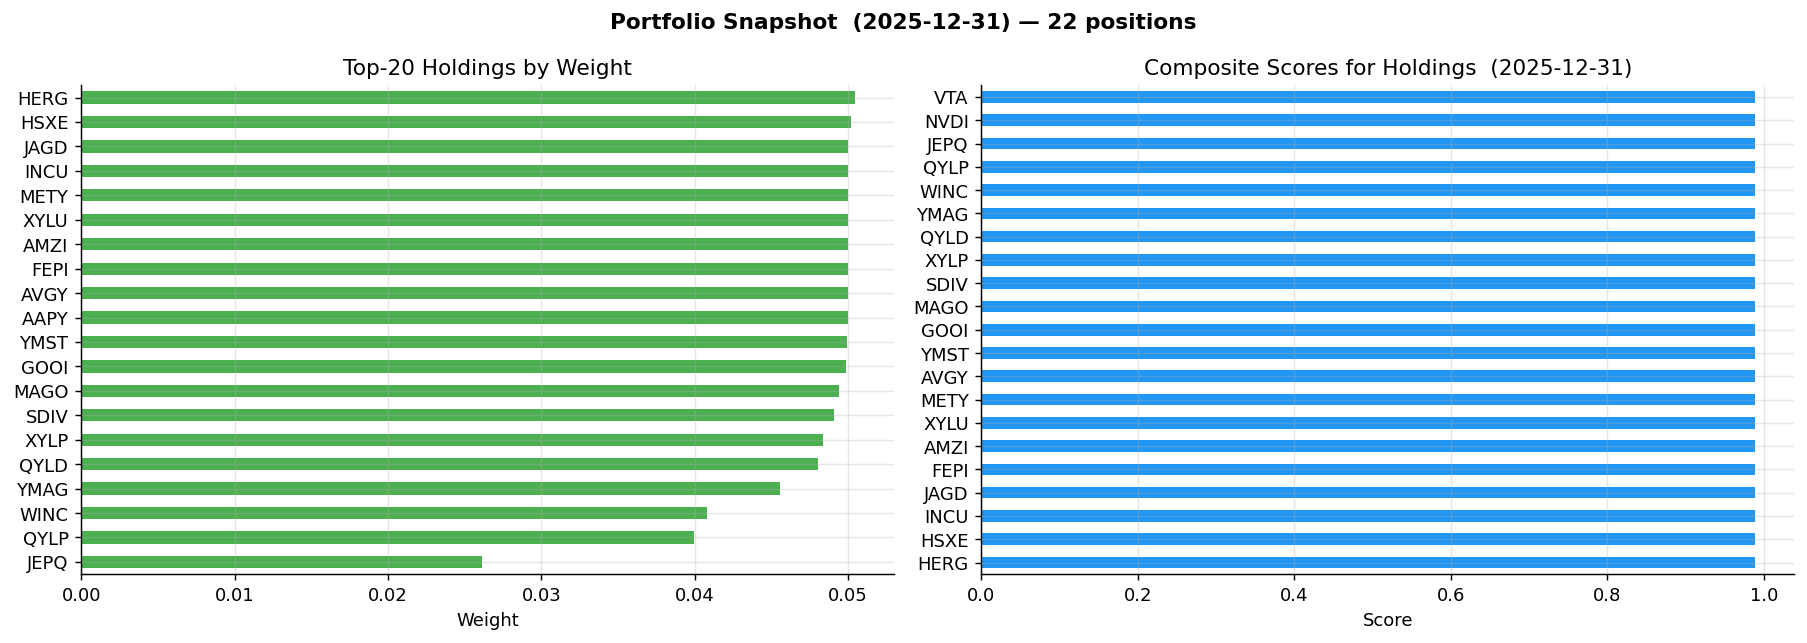

Top holdings:
HERG    0.050457
HSXE    0.050204
INCU    0.050005
JAGD    0.050005
FEPI    0.050005
AMZI    0.050005
XYLU    0.050005
METY    0.050005
AVGY    0.050005
AAPY    0.050005
YMST    0.049902
GOOI    0.049841
MAGO    0.049399
SDIV    0.049106
XYLP    0.048369
QYLD    0.048035
YMAG    0.045545
WINC    0.040787
QYLP    0.039967
JEPQ    0.026114


In [239]:
# Latest portfolio snapshot (matplotlib barh)
latest_date = wts.index[wts.abs().sum(axis=1) > 0][-1]
latest_wts  = wts.loc[latest_date].dropna()
latest_wts  = latest_wts[latest_wts.abs() > 1e-4].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Portfolio Snapshot  ({latest_date.date()}) — {len(latest_wts)} positions',
             fontsize=12, fontweight='bold')

latest_wts.head(20).sort_values().plot(kind='barh', ax=axes[0], color='#4CAF50')
axes[0].set_title('Top-20 Holdings by Weight')
axes[0].set_xlabel('Weight')

# Composite scores for current holdings on the nearest signal date
nearest_signal = composite.index[composite.index.get_indexer([latest_date], method='nearest')[0]]
scores_now = composite.loc[nearest_signal].reindex(latest_wts.index).dropna().sort_values(ascending=False)
scores_now.sort_values().plot(kind='barh', ax=axes[1], color='#2196F3')
axes[1].set_title(f'Composite Scores for Holdings  ({nearest_signal.date()})')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()
print('Top holdings:')
print(latest_wts.head(20).to_string())

In [240]:

# ── Ticker Diagnostics: Who is actually in the portfolio? ────────────────────
# List all tickers that appeared in the portfolio at least once
ever_held = wts.columns[(wts.abs() > 1e-4).any()].tolist()
print(f'Total unique tickers ever held: {len(ever_held)}')
print()

# Show latest portfolio with cross-ref to price data availability
print(f'Latest portfolio  ({latest_date.date()}):')
for tk in latest_wts.index:
    wt = latest_wts[tk]
    # Nearest composite score
    sc = composite.loc[nearest_signal, tk] if tk in composite.columns else float('nan')
    # Trailing dividend yield (raw, not ranked)
    dy_val = div_income.loc[nearest_signal, tk] if tk in div_income.columns else float('nan')
    # Latest price
    px_val = adj_px.loc[adj_px.index <= latest_date, tk].dropna()
    px_last = px_val.iloc[-1] if len(px_val) > 0 else float('nan')
    print(f'  {tk:<20}  wt={wt:.3f}  score={sc:.3f}  div_yield≈{dy_val:.4f}  last_px={px_last:.2f}')


Total unique tickers ever held: 231

Latest portfolio  (2025-12-31):
  HERG                  wt=0.050  score=0.989  div_yield≈2.5249  last_px=4.33
  HSXE                  wt=0.050  score=0.989  div_yield≈5.3233  last_px=7.71
  INCU                  wt=0.050  score=0.989  div_yield≈0.3843  last_px=4.05
  JAGD                  wt=0.050  score=0.989  div_yield≈0.7783  last_px=7.69
  FEPI                  wt=0.050  score=0.989  div_yield≈2.9015  last_px=23.72
  AMZI                  wt=0.050  score=0.989  div_yield≈1.3659  last_px=9.41
  XYLU                  wt=0.050  score=0.989  div_yield≈1.6296  last_px=15.03
  METY                  wt=0.050  score=0.989  div_yield≈1.7905  last_px=8.42
  AVGY                  wt=0.050  score=0.989  div_yield≈4.4044  last_px=33.17
  AAPY                  wt=0.050  score=nan  div_yield≈1.0040  last_px=8.86
  YMST                  wt=0.050  score=0.989  div_yield≈1.8115  last_px=9.80
  GOOI                  wt=0.050  score=0.989  div_yield≈1.6131  last_px

In [241]:
# ── Company Metadata: name, sector, country, ISIN from eodhd.instruments ─────
try:
    import psycopg2
except ModuleNotFoundError:
    %pip install psycopg2-binary -q
    import psycopg2

DB = dict(host='localhost', dbname='sfera', user='postgres', password='lokomotiv')

with psycopg2.connect(**DB) as _conn:
    _tickers_all = ever_held  # all tickers ever in portfolio
    meta = pd.read_sql(
        """
        SELECT ticker, name, country, currency, sector, industry, isin
        FROM eodhd.instruments
        WHERE exchange_code = 'LSE'
          AND ticker = ANY(%(tickers)s)
        """,
        _conn,
        params={'tickers': _tickers_all},
    )

meta = meta.set_index('ticker')
print(f'Metadata loaded for {len(meta)} / {len(_tickers_all)} ever-held tickers')
print(f'\nCountry breakdown (ever held):\n{meta["country"].value_counts().head(15).to_string()}')
print(f'\nSector breakdown (ever held):\n{meta["sector"].value_counts().head(15).to_string()}')

# ── Enrich latest portfolio snapshot ─────────────────────────────────────────
snap = latest_wts.to_frame('weight')
snap = snap.join(meta[['name', 'country', 'sector', 'isin']], how='left')

# Add current composite score and trailing yield
snap['score']     = composite.loc[nearest_signal].reindex(snap.index)
snap['yield_ttm'] = div_income.loc[nearest_signal].reindex(snap.index)
snap['eps_yoy']   = eps_yoy.loc[nearest_signal].reindex(snap.index)

snap = snap.sort_values('weight', ascending=False)
print(f'\n=== Latest Portfolio ({latest_date.date()}) — enriched ===')
pd.set_option('display.max_colwidth', 35)
pd.set_option('display.width', 160)
print(snap[['name', 'country', 'sector', 'weight', 'score', 'yield_ttm', 'eps_yoy', 'isin']].to_string())


Metadata loaded for 60 / 231 ever-held tickers

Country breakdown (ever held):
country
GB    60

Sector breakdown (ever held):
sector
                      52
Financial Services     5
Consumer Cyclical      1
Basic Materials        1
Energy                 1

=== Latest Portfolio (2025-12-31) — enriched ===
                       name country sector    weight     score  yield_ttm  eps_yoy  isin
HERG                    NaN     NaN    NaN  0.050457  0.989154    2.52489      NaN   NaN
HSXE                    NaN     NaN    NaN  0.050204  0.989154    5.32328      NaN   NaN
INCU                    NaN     NaN    NaN  0.050005  0.989154    0.38430      NaN   NaN
JAGD                    NaN     NaN    NaN  0.050005  0.989154    0.77827      NaN   NaN
FEPI                    NaN     NaN    NaN  0.050005  0.989154    2.90150      NaN   NaN
AMZI                    NaN     NaN    NaN  0.050005  0.989154    1.36589      NaN   NaN
XYLU                    NaN     NaN    NaN  0.050005  0.989154    1.

---
## 5c — Single Name Deep Dive
Full signal computation walkthrough for one name — EPS history, trailing dividend, composite rank, price and portfolio contribution, all synchronized in a Signum Dashboard.

Change `EXAMPLE_TICKER` to inspect any holding.


In [246]:
from signum import Dashboard

# ─────────────────────────────────────────────────────────────────────────────
# NOTE ON TICKER FORMAT:
#   Data uses SHORT codes from eodhd.prices (e.g. 'SHEL', 'BP', 'HSBA')
#   NOT 'SHEL.LSE' style.  Use find_ticker() below to look up the right code.
#
# SET THIS — short code from composite.columns, e.g. 'SHEL', 'BP', 'HSBA'
# Leave as None to auto-select the most-held name that HAS EPS data
DRILLDOWN_TICKER = 'BP.LSE'
# ─────────────────────────────────────────────────────────────────────────────

# ── Helper: resolve ticker by partial match against short codes + company names ──
def find_ticker(query: str, top_n: int = 10) -> list:
    """Search by partial ticker code or company name.
    Examples:  find_ticker('SHEL')  /  find_ticker('Shell')
    """
    q = query.strip().upper()
    hold_counts = (wts[ever_held].abs() > 1e-4).sum() if ever_held else pd.Series(dtype=int)
    results = {}
    for col in composite.columns:
        if q in col.upper():
            results[col] = hold_counts.get(col, 0)
    if 'name' in meta.columns:
        for tk in meta[meta['name'].str.upper().str.contains(q, na=False)].index:
            if tk not in results:
                results[tk] = hold_counts.get(tk, 0)
    sorted_results = sorted(results.items(), key=lambda x: (-x[1], x[0]))[:top_n]
    if not sorted_results:
        print(f'No tickers found matching "{query}". Sample codes: {list(composite.columns[:15])}')
        return []
    print(f'Matches for "{query}":')
    print(f'  {"Code":<12} {"Company name":<40} {"EPS data":>10} {"Hold days":>10}')
    print(f'  {"-"*12} {"-"*40} {"-"*10} {"-"*10}')
    for tk, days in sorted_results:
        nm  = meta.at[tk, 'name'] if tk in meta.index else '(no metadata)'
        eps = f'{eps_yoy[tk].dropna().shape[0]} obs' if tk in eps_yoy.columns else 'none'
        port = f'{days} days' if days > 0 else '(not held)'
        print(f'  {tk:<12} {str(nm):<40} {eps:>10} {port:>10}')
    return [tk for tk, _ in sorted_results]

# ── Quick lookup examples (uncomment to search):
# find_ticker('SHEL')    # Shell
# find_ticker('BP')      # BP plc
# find_ticker('HSBA')    # HSBC
# find_ticker('AZN')     # AstraZeneca
# ────────────────────────────────────────────────────────────────────────────

# ── Auto-pick: prefer most-held ticker that HAS EPS data ─────────────────────
if DRILLDOWN_TICKER is None:
    hold_days = (wts[ever_held].abs() > 1e-4).sum()
    has_eps = [tk for tk in ever_held
               if tk in eps_yoy.columns and eps_yoy[tk].dropna().shape[0] > 3]
    if has_eps:
        _candidate = hold_days.reindex(has_eps).idxmax()
        print(f'Auto-selected (most-held WITH EPS data): {_candidate}  ({hold_days[_candidate]} days)')
    else:
        _candidate = hold_days.idxmax()
        print(f'Auto-selected (most-held, WARNING no EPS available): {_candidate}')
    DRILLDOWN_TICKER = _candidate
    print(f'\nTop-10 most held  (✓ = has EPS data):')
    for tk, d in hold_days.nlargest(10).items():
        nm       = meta.at[tk, 'name'] if tk in meta.index else tk
        eps_mark = '✓' if tk in has_eps else ' '
        print(f'  [{eps_mark}] {tk:<12} {str(nm):<40} {d} days')
    print()

TK = DRILLDOWN_TICKER

# ── Resolve ticker if user typed .LSE suffix or partial ──────────────────────
if TK not in composite.columns:
    print(f'WARNING: "{TK}" not found in signal data.')
    print(f'  Data uses short codes e.g. "SHEL" not "SHEL.LSE"')
    stripped = TK.replace('.LSE', '').replace('.L', '')
    if stripped in composite.columns:
        print(f'  Auto-corrected: "{TK}" -> "{stripped}"')
        TK = stripped
    else:
        candidates = find_ticker(stripped)
        if candidates:
            TK = candidates[0]
            print(f'\n  Using first match: {TK}')
        else:
            print(f'  Set DRILLDOWN_TICKER to one of: {ever_held[:20]}')
            raise ValueError(f'Cannot resolve ticker "{DRILLDOWN_TICKER}"')

# ── Common daily date index — all panes aligned to THIS for x-axis sync ──────
_daily_idx = pd.date_range(start=start_trade, end=end_trade, freq='B')

def _align(s: pd.Series, ffill=False) -> pd.Series:
    """Reindex to the common business-day grid."""
    if len(s) == 0:
        return pd.Series(dtype=float, index=_daily_idx)
    full_idx = s.index.union(_daily_idx).sort_values()
    s2 = s.reindex(full_idx)
    if ffill:
        s2 = s2.ffill()
    return s2.reindex(_daily_idx)

# ── Raw data ──────────────────────────────────────────────────────────────────
_comp_raw   = composite[TK].dropna()    if TK in composite.columns  else pd.Series(dtype=float)
_div_raw    = div_income[TK].dropna()   if TK in div_income.columns else pd.Series(dtype=float)
# eps_yoy_raw.parquet is ALREADY daily (build_signals.py ffills quarterly reports
# to the full trading-date calendar before saving).  Do NOT dropna() here —
# NaN at the start just means no report had been filed yet for this ticker.
_eps_raw    = eps_yoy[TK]               if TK in eps_yoy.columns    else pd.Series(dtype=float)
_px_adj_raw = adj_px[TK].dropna()       if TK in adj_px.columns     else pd.Series(dtype=float)
_px_u_raw   = close_px[TK].dropna()     if TK in close_px.columns   else pd.Series(dtype=float)
_wt_raw     = wts[TK].fillna(0)         if TK in wts.columns        else pd.Series(0.0, index=wts.index)

# Aligned to common daily index
_comp   = _align(_comp_raw,   ffill=False)
_eps    = _align(_eps_raw,    ffill=False)  # already daily-ffilled by build_signals
_px_adj = _align(_px_adj_raw, ffill=False)
_wt     = _align(_wt_raw,     ffill=True)

# ── Trailing yield — with raw-value sanity check ──────────────────────────────
# div_income stores trailing 12M dividends per share in the SAME units as eodhd.prices
# (could be GBX pence for UK domestic stocks, or USD for dual-listed like SHEL/BP).
# If currency units differ between div_income and close_px, the yield will be wrong.
if len(_div_raw) > 0 and len(_px_u_raw) > 0:
    _px_for_yield = _px_u_raw.reindex(_div_raw.index, method='ffill').replace(0, float('nan'))
    _yld_raw = (_div_raw / _px_for_yield * 100).dropna()
    _yield   = _align(_yld_raw, ffill=True)

    # ── Sanity check: print raw numerator/denominator so you can verify units ──
    _recent_div = _div_raw.iloc[-1] if len(_div_raw) else float('nan')
    _recent_px  = _px_for_yield.dropna().iloc[-1] if len(_px_for_yield.dropna()) else float('nan')
    _recent_yld = _yld_raw.iloc[-1] if len(_yld_raw) else float('nan')
    print(f'  ── Yield sanity check ({TK}) ──')
    print(f'     Trailing 12M div (raw units from div_income) : {_recent_div:.4f}')
    print(f'     Unadj close price (raw units from close_px)  : {_recent_px:.4f}')
    print(f'     Computed yield = div/price × 100             : {_recent_yld:.2f}%')
    print(f'     NOTE: if both are in GBX (pence), yield is correct.')
    print(f'           if div is in GBP and price in GBX, multiply yield × 100.')
    print(f'           if div is in USD and price in GBX, need FX conversion.')
    print()
else:
    _yield = pd.Series(dtype=float)

# ── Cross-sectional rank CONTRIBUTIONS (what actually sums to composite) ──────
# IMPORTANT: composite was built on YIELD (div/price, capped at 40%), NOT raw div amount.
# Ranking raw div_income cross-sectionally would be wrong — it conflates dividend size
# with yield and is corrupted by GBP/GBX unit mismatches across tickers.
# We replicate the exact yield computation from build_signals.py here.
print('Computing cross-sectional rank contributions (yield = div/price, cap 40%)...')
if TK in div_income.columns and len(_div_raw) > 0:
    # Align close_px to div_income index for yield = div / price
    _close_for_rank = close_px.reindex(div_income.index, method='ffill').replace(0, np.nan)
    _yield_matrix   = div_income.div(_close_for_rank)                       # raw yield (decimal)
    _yield_matrix   = _yield_matrix.where(_yield_matrix > 0.001)            # must be a real payer
    _yield_matrix   = _yield_matrix.where(_yield_matrix <= 0.40)            # cap 40% (same as build_signals)
    _div_cs_rank    = _yield_matrix.rank(axis=1, pct=True, na_option='keep')[TK].dropna()
    _div_contrib    = _align(_div_cs_rank * 0.4, ffill=True)                # 0 – 0.4
else:
    _div_contrib = pd.Series(dtype=float)

if TK in eps_yoy.columns and _eps_raw.dropna().shape[0] > 0:
    _eps_cs_rank = eps_yoy.rank(axis=1, pct=True, na_option='keep')[TK].dropna()
    _eps_contrib = _align(_eps_cs_rank * 0.6, ffill=True)   # 0 – 0.6
else:
    _eps_contrib = pd.Series(dtype=float)
print('Done.')

# Contribution NAV
_held = int((_wt_raw.abs() > 1e-4).sum())
if len(_px_adj_raw) > 0:
    _pnl      = (_px_adj_raw.pct_change() * _wt_raw.reindex(_px_adj_raw.index, method='ffill').fillna(0))
    _pnl      = _pnl.loc[start_trade:end_trade].dropna()
    _nav_name = (1 + _pnl).cumprod() if len(_pnl) > 0 else pd.Series(dtype=float)
    _nav_aln  = _align(_nav_name, ffill=False) if len(_nav_name) > 0 else pd.Series(dtype=float)
    if len(_pnl) > 1:
        _n_cagr = float(_nav_name.iloc[-1]) ** (252 / len(_pnl)) - 1
        _n_vol  = float(_pnl.std()) * np.sqrt(252)
        _cum    = (1 + _pnl).cumprod()
        _n_dd   = float((_cum / _cum.cummax() - 1).min())
    else:
        _n_cagr = _n_vol = _n_dd = 0.0
else:
    _nav_aln, _n_cagr, _n_vol, _n_dd = pd.Series(dtype=float), 0.0, 0.0, 0.0

# ── Metadata ──────────────────────────────────────────────────────────────────
_isin  = meta.at[TK, 'isin']    if TK in meta.index else 'n/a'
_name  = meta.at[TK, 'name']    if TK in meta.index else TK
_sect  = meta.at[TK, 'sector']  if TK in meta.index else 'n/a'
_cntry = meta.at[TK, 'country'] if TK in meta.index else 'n/a'

print(f'\n=== Drilldown: {_name} ({TK}) ===')
print(f'  ISIN      : {_isin}   |   Country: {_cntry}   |   Sector: {_sect}')
print(f'  Portfolio : {_held} days  ({"HELD" if _held > 0 else "NEVER HELD — signal history only"})')

print(f'\n  Data availability -> pane inclusion:')
print(f'    EPS YoY obs  : {_eps_raw.dropna().shape[0]:>5}  -> {"PANE 1: EPS baseline" if _eps.dropna().shape[0] > 0 else "PANE 1 SKIPPED — no EPS data"}')
print(f'    Div yield    : {len(_div_raw):>5}  -> {"PANE 2: div yield %" if _yield.dropna().shape[0] > 0 else "PANE 2 SKIPPED — no div data"}')
print(f'    Composite    : {len(_comp_raw):>5}  -> {"PANE 3: composite + contributions" if _comp.dropna().shape[0] > 0 else "PANE 3 SKIPPED"}')
print(f'      yield contrib (×0.4): {"YES (green)" if _div_contrib.dropna().shape[0] > 0 else "NO"}')
print(f'      EPS contrib  (×0.6): {"YES (orange)" if _eps_contrib.dropna().shape[0] > 0 else "NO"}')
print(f'    Price (adj)  : {len(_px_adj_raw):>5}  -> {"PANE 4: price" if _px_adj.dropna().shape[0] > 0 else "PANE 4 SKIPPED — no price"}')
print(f'    Held (days)  : {_held:>5}  -> {"PANE 5+6: contrib NAV + weight" if _held > 0 else "PANE 5+6 SKIPPED — never held"}')
print()

if _yield.dropna().shape[0]:
    print(f'  Div yield : latest {_yield.dropna().iloc[-1]:.2f}%  avg {_yield.dropna().mean():.2f}%')
if _eps_raw.dropna().shape[0]:
    print(f'  EPS YoY   : latest {_eps_raw.dropna().iloc[-1]:.4f}  avg {_eps_raw.dropna().mean():.4f}  ({_eps_raw.dropna().shape[0]} obs)')
if _comp_raw.shape[0]:
    print(f'  Composite : latest {_comp_raw.iloc[-1]:.3f}  avg {_comp_raw.mean():.3f}')
if _div_contrib.dropna().shape[0]:
    print(f'  Yield ×0.4: latest {_div_contrib.dropna().iloc[-1]:.3f}  (yield cs-rank = {_div_contrib.dropna().iloc[-1]/0.4:.3f})')
if _eps_contrib.dropna().shape[0]:
    print(f'  EPS ×0.6  : latest {_eps_contrib.dropna().iloc[-1]:.3f}  (EPS cs-rank = {_eps_contrib.dropna().iloc[-1]/0.6:.3f})')
if _held > 0 and len(_nav_name) > 1:
    print(f'  Contrib   : CAGR {_n_cagr:.2%}  vol {_n_vol:.2%}  maxDD {_n_dd:.2%}')
print()

# ── Build Dashboard ───────────────────────────────────────────────────────────
panes, titles = [], []

# PANE 1 — EPS YoY baseline (already daily from build_signals ffill)
if _eps.dropna().shape[0] > 0:
    panes.append(Chart(height=165).baseline(_eps.rename('EPS YoY'), base_value=0, title='EPS YoY'))
    titles.append(f'{_name}  ({TK} | {_isin})  —  EPS YoY Growth  [quarterly, step-filled]')

# PANE 2 — Trailing dividend yield %
if _yield.dropna().shape[0] > 0:
    panes.append(Chart(height=145).area(_yield.rename('Div Yield %'), name='Div Yield %'))
    titles.append('Trailing 12-Month Dividend Yield (%) — check "Yield sanity check" printout above if values look wrong')

# PANE 3 — Composite with factor contributions
if _comp.dropna().shape[0] > 0:
    c3 = Chart(height=185).line(
        _comp.rename('Composite'), name='Composite (0.4·yield + 0.6·EPS)', color='#2196F3', width=2
    )
    if _div_contrib.dropna().shape[0] > 0:
        c3 = c3.line(_div_contrib.rename('Yield ×0.4'), name='Yield ×0.4', color='#4CAF50', width=1)
    if _eps_contrib.dropna().shape[0] > 0:
        c3 = c3.line(_eps_contrib.rename('EPS ×0.6'), name='EPS ×0.6', color='#FF9800', width=1)
    panes.append(c3)
    titles.append('Composite (blue)  =  Yield contrib ×0.4 (green)  +  EPS contrib ×0.6 (orange)')

# PANE 4 — Adj close price
if _px_adj.dropna().shape[0] > 0:
    panes.append(Chart(height=210).line(
        _px_adj.rename('Price adj £'), name='Price adj £', color='#9C27B0', width=2
    ))
    titles.append('Adj Close Price (£, dividends reinvested)')

# PANE 5 — Contribution NAV
if _held > 0 and _nav_aln.dropna().shape[0] > 5:
    panes.append(
        Chart(height=155)
        .line(_nav_aln.rename('Contrib NAV'), name='Contrib NAV', color='#FF5722', width=2)
        .stats_legend({'CAGR': f'{_n_cagr:.2%}', 'Vol': f'{_n_vol:.2%}', 'Max DD': f'{_n_dd:.2%}'}, position='top-left')
    )
    titles.append('Portfolio Contribution NAV  (weighted daily return, base = 1.0)')

# PANE 6 — Portfolio weight
if _held > 0 and _wt.abs().max() > 1e-4:
    panes.append(Chart(height=110).area(_wt.rename('Weight'), name='Weight'))
    titles.append('Portfolio Weight')

if panes:
    Dashboard(panes=panes, titles=titles).show()
else:
    print(f'No signal or price data found for {TK}')


  Data uses short codes e.g. "SHEL" not "SHEL.LSE"
  Auto-corrected: "BP.LSE" -> "BP"
  ── Yield sanity check (BP) ──
     Trailing 12M div (raw units from div_income) : 0.2458
     Unadj close price (raw units from close_px)  : 572.6000
     Computed yield = div/price × 100             : 0.04%
     NOTE: if both are in GBX (pence), yield is correct.
           if div is in GBP and price in GBX, multiply yield × 100.
           if div is in USD and price in GBX, need FX conversion.

Computing cross-sectional rank contributions...
Done.

=== Drilldown: BP (BP) ===
  ISIN      : n/a   |   Country: n/a   |   Sector: n/a
  Portfolio : 0 days  (NEVER HELD — signal history only)

  Data availability -> pane inclusion:
    EPS YoY obs  :  2923  -> PANE 1: EPS baseline
    Div yield    :  2923  -> PANE 2: div yield %
    Composite    :  2864  -> PANE 3: composite + contributions
      yield contrib (×0.4): YES (green)
      EPS contrib  (×0.6): YES (orange)
    Price (adj)  :  3370  -> PANE 4:

---
## 6 — Return Attribution: Dividend Income vs Capital Gain
Decompose portfolio return into:  
- **Capital gain**: from `close_price` (unadjusted, excludes dividends)  
- **Dividend income**: `adj_close` total return minus capital gain component

In [243]:
# Forward-fill weights to daily price index
wts_aligned = wts.reindex(adj_px.index, method='ffill').fillna(0)

# Daily returns by component
total_daily = adj_px.pct_change()    # total return (dividends included in adj close)
price_daily = close_px.pct_change()  # capital gain only (unadjusted close)
div_daily   = total_daily - price_daily  # dividend component

# Portfolio-weighted returns (only tickers present in both weights and prices)
shared = wts_aligned.columns.intersection(total_daily.columns)
port_total = (total_daily[shared] * wts_aligned[shared]).sum(axis=1)
port_price = (price_daily[shared] * wts_aligned[shared]).sum(axis=1)
port_div   = (div_daily[shared]   * wts_aligned[shared]).sum(axis=1)

# Restrict to active backtest period
mask = (port_total.index >= start_trade) & (port_total.index <= end_trade)
port_total = port_total[mask]
port_price = port_price[mask]
port_div   = port_div[mask]

# Cumulative NAVs
cum_total = (1 + port_total).cumprod()
cum_price = (1 + port_price).cumprod()
cum_div   = (1 + port_div).cumprod()

# Annualised summary
n_years    = len(cum_total) / 252
total_ann  = (cum_total.iloc[-1] ** (1 / n_years) - 1) * 100
price_ann  = (cum_price.iloc[-1] ** (1 / n_years) - 1) * 100
div_ann    = (cum_div.iloc[-1]   ** (1 / n_years) - 1) * 100

print('=== Return Attribution (annualised) ===')
print(f'  Total return    : {total_ann:.2f}%')
print(f'  Capital gain    : {price_ann:.2f}%')
print(f'  Dividend income : {div_ann:.2f}%')
if total_ann > 0:
    print(f'  Dividend share  : {div_ann / total_ann * 100:.1f}% of total return')

# Interactive multi-line chart (Signum)
chart = Chart(height=380)
chart.line(cum_total.rename('Total Return'),  name='Total Return (adj close)',   color='#2196F3', width=2)
chart.line(cum_price.rename('Capital Gain'),  name='Capital Gain (unadj close)', color='#4CAF50', width=2)
chart.line(cum_div.rename('Div Factor'),      name='Dividend Multiplier',        color='#FF9800', width=2)
chart.show()

=== Return Attribution (annualised) ===
  Total return    : 15.67%
  Capital gain    : 4.62%
  Dividend income : 10.53%
  Dividend share  : 67.2% of total return


---
## 7 — Trades Analysis

=== Transaction Summary ===
  Total trades      : 63,264
  Total notional    : 353.6M
  Total commission  : 353,566
  Total slippage    : 122,119
  Avg commission bps: 10.00

Annual breakdown:
      n_trades  notional_M    commission
year                                    
2015      5512   19.129226  19129.226485
2016      5645   26.867659  26867.658614
2017      5586   28.354164  28354.163816
2018      5745   29.084878  29084.878365
2019      5746   39.065268  39065.267808
2020      5921   43.427038  43427.038011
2021      5736   37.419703  37419.703180
2022      5636   35.175213  35175.213063
2023      5746   28.070425  28070.424635
2024      5970   35.949824  35949.823807
2025      6021   31.022732  31022.732500


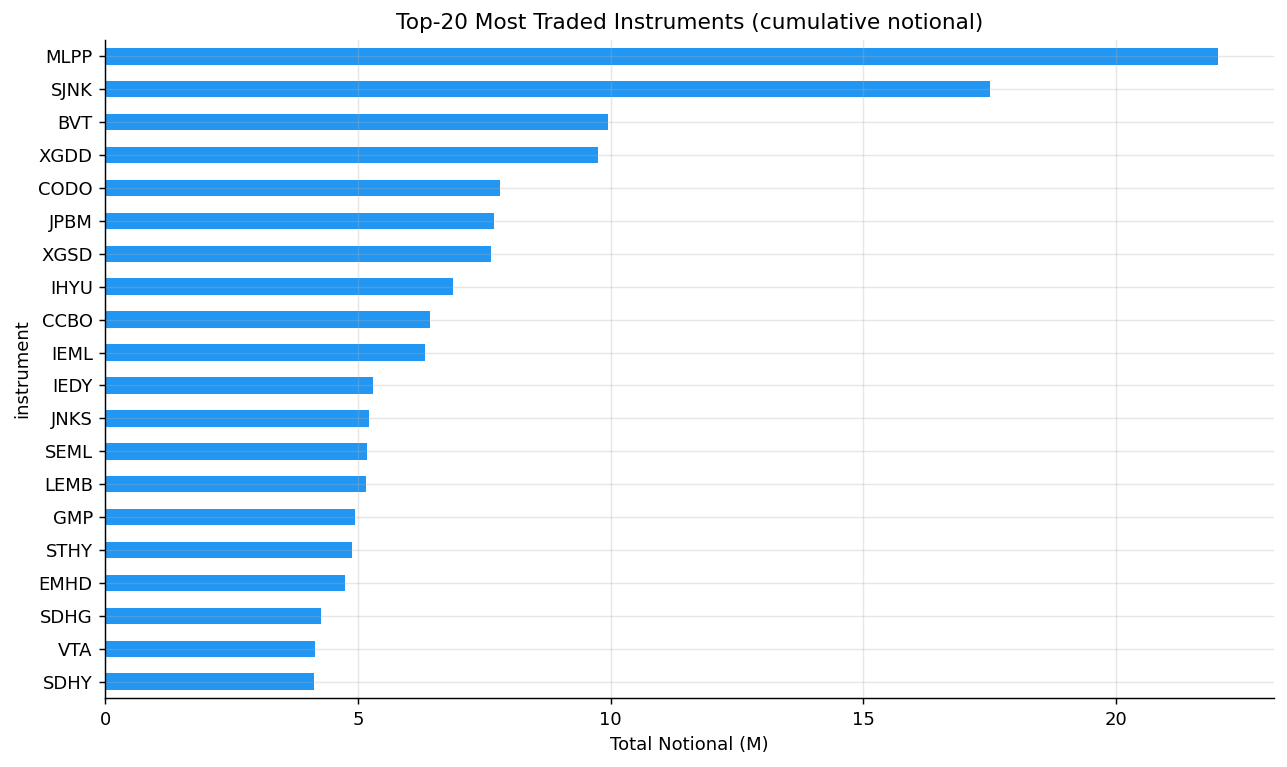

In [244]:
# Column name normalisation
if 'ticker' in trades.columns and 'instrument' not in trades.columns:
    trades = trades.rename(columns={'ticker': 'instrument'})

if 'datetime' in trades.columns:
    trades['year'] = trades['datetime'].dt.year

total_notional   = trades['notional'].abs().sum() if 'notional' in trades.columns else 0
total_commission = trades['commission'].sum() if 'commission' in trades.columns else 0
total_slippage   = (trades['slippage_bps'] * trades['notional'].abs() / 10000).sum() \
    if 'slippage_bps' in trades.columns else 0

print('=== Transaction Summary ===')
print(f'  Total trades      : {len(trades):,}')
print(f'  Total notional    : {total_notional / 1e6:.1f}M')
print(f'  Total commission  : {total_commission:,.0f}')
print(f'  Total slippage    : {total_slippage:,.0f}')
if total_notional > 0:
    print(f'  Avg commission bps: {total_commission / total_notional * 10000:.2f}')

if 'year' in trades.columns:
    agg = {'n_trades': ('instrument', 'count'),
           'notional_M': ('notional', lambda x: x.abs().sum() / 1e6)}
    if 'commission' in trades.columns:
        agg['commission'] = ('commission', 'sum')
    annual = trades.groupby('year').agg(**agg)
    print(f'\nAnnual breakdown:\n{annual.to_string()}')

# Most traded instruments (by cumulative notional)
if 'instrument' in trades.columns and 'notional' in trades.columns:
    top_traded = (
        trades.groupby('instrument')['notional']
        .apply(lambda x: x.abs().sum())
        .nlargest(20)
        .div(1e6)
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    top_traded.sort_values().plot(kind='barh', ax=ax, color='#2196F3')
    ax.set_title('Top-20 Most Traded Instruments (cumulative notional)')
    ax.set_xlabel('Total Notional (M)')
    plt.tight_layout()
    plt.show()

---
## 8 — Next Iterations

| Variant | Change | Expected Impact |
|---------|--------|----------------|
| `002_top30` | Increase N to 30 | Reduce concentration, smoother DD |
| `003_eps_heavy` | Weights 0.3 yield / 0.7 EPS | Tilt towards growing earners |
| `004_profit_filter` | Add `profit_margin > 0` filter | Exclude dividend traps (loss-makers paying out capital) |
| `005_momentum` | Add 6M price momentum to composite | Dividend growers + momentum = compounder screen |

To run a new variant:
```
# 1. Copy 001_baseline/ to 002_top30/
# 2. Edit strategy.py: change TopN(n=20) -> TopN(n=30)
# 3. cd btest && uv run python "research/LSE Dividend EPS/002_top30/strategy.py"
```